# 3I - Interpretacao integrada da Fase 3 (Pacifico; NOAA/ONI local)

**Pergunta especifica.** Depois de 3A-3H/3K, qual conjunto de variaveis explica o aquecimento maximo do El Nino com antecedencia, quais evidencias entram no parecer e como ler a janela 2025/26 sem fingir uma previsao ainda nao validada?

**Objetivo.** Consolidar evidencias/limites em saida unica rastreavel a tabelas ja materializadas, separando: precursores, variaveis de estado simultaneo, severidade acumulada e redundancia fisica.

**Justificativa.** A Fase 3 precisa ser legivel para preparar uma futura projecao do pico de 2026. Ela identifica variaveis antecedentes e lags plausiveis, mas a projecao numerica futura pertence a uma etapa de modelagem/validacao walk-forward.

**Metodologia.** Combina ranking 3D, estabilidade 3E, classes NOAA/ONI locais, estado 2025/26 e PCA 3K. Evento = media movel de 3 meses >=+0,5 C por 5+ estacoes sobrepostas; intensidade = pico dessa media: fraco, moderado, forte, muito forte/super.

**Saidas.** `phase3I_conclusoes_decisao.csv`, `phase3I_conjunto_antecipacao_pico.csv`, `phase3I_classificacao_noaa_oni.csv`, `phase3I_medias_classes_noaa.csv`, `phase3I_estado_2026.csv`, `phase3I_sintese_parecer.png`, `phase3I_antecipacao_pico.png`.


In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u

d3 = pd.read_csv(u.STATS/'phase3D_ranking_significativo.csv').set_index('variavel')
e3 = pd.read_csv(u.STATS/'phase3E_estabilidade.csv').set_index('variavel')
assert not any('atl' in v for v in d3.index), 'Atlantico ainda presente!'
print('Variaveis no parecer (todas Pacifico):', list(d3.index))
bloco = {
    'tilt_m':'recarga/subsuperficie', 'ssh_m':'recarga/subsuperficie', 'ohc_0_300':'recarga/subsuperficie',
    'ohc_0_700':'recarga/subsuperficie', 'd20_m':'recarga/subsuperficie', 'wwv':'recarga/subsuperficie',
    'tau_x_anom_nino34_pa':'vento/acoplamento', 'dhw_cweek_0p5_12w':'calor acumulado',
}
rows = []
for v in d3.index:
    estavel = bool(e3.loc[v, 'estavel']) if v in e3.index else False
    lag = int(d3.loc[v, 'lag_semanas'])
    r = float(d3.loc[v, 'r'])
    if lag >= 12 and estavel:
        papel = 'precursor antecipado'
        uso = 'entra como candidato para previsao do pico'
    elif lag > 0:
        papel = 'precursor curto/medio prazo'
        uso = 'entra como apoio diagnostico'
    else:
        papel = 'estado simultaneo/acoplado'
        uso = 'entra como diagnostico de estado'
    if not estavel:
        uso = 'entra com ressalva (regime-dependente)'
    rows.append({'variavel':v, 'rotulo':u.var_label(v, short=True), 'bloco':bloco.get(v, '-'), 'lag_semanas':lag, 'r':round(r, 3), 'abs_r':round(abs(r), 3), 'estavel_3E':estavel, 'papel':papel, 'uso_parecer':uso})
conc = pd.DataFrame(rows).sort_values(['abs_r','lag_semanas'], ascending=[False, False])
u.save_table(conc, 'phase3I_conclusoes_decisao.csv', index=False)
antecip = conc.assign(horizonte=np.select([conc['lag_semanas']>=26, conc['lag_semanas']>=12, conc['lag_semanas']>0], ['longo (>=6 meses)','medio (3-6 meses)','curto (<3 meses)'], default='simultaneo'))
antecip['interpreta_para_2026'] = antecip.apply(lambda r: 'priorizar na futura projecao de pico' if (r['estavel_3E'] and r['lag_semanas']>=12) else ('usar como estado/acoplamento atual' if r['lag_semanas']<=6 else 'usar com cautela'), axis=1)
u.save_table(antecip, 'phase3I_conjunto_antecipacao_pico.csv', index=False)
print(antecip[['rotulo','bloco','lag_semanas','r','estavel_3E','horizonte','interpreta_para_2026']].to_string(index=False))


Variaveis no parecer (todas Pacifico): ['tilt_m', 'ssh_m', 'ohc_0_300', 'ohc_0_700', 'dhw_cweek_0p5_12w', 'd20_m', 'wwv', 'tau_x_anom_nino34_pa']
[tabela] data\processed\parquet\statistics\phase3I_conclusoes_decisao.csv
[tabela] data\processed\parquet\statistics\phase3I_conjunto_antecipacao_pico.csv
     rotulo                 bloco  lag_semanas     r  estavel_3E         horizonte                 interpreta_para_2026
       Tilt recarga/subsuperficie            0 0.772        True        simultaneo   usar como estado/acoplamento atual
        SSH recarga/subsuperficie            6 0.755        True  curto (<3 meses)   usar como estado/acoplamento atual
   OHC0-300 recarga/subsuperficie            6 0.738        True  curto (<3 meses)   usar como estado/acoplamento atual
   OHC0-700 recarga/subsuperficie            6 0.701        True  curto (<3 meses)   usar como estado/acoplamento atual
  DHW gated       calor acumulado            0 0.638        True        simultaneo   usar como esta

In [2]:
ev_all = u.events_noaa()
counts = ev_all['classe_noaa'].value_counts().to_dict()
classes = u.elnino_mean_group_table()[['grupo','rotulo','definicao']].copy()
classes['n_eventos'] = classes['grupo'].map(lambda g: int(counts.get(g,0)))
classes['limiar_evento_oni_c'] = 0.5
classes['criterio_temporal'] = 'media movel de 3 meses >=+0.5 C por 5+ estacoes sobrepostas'
classes['fonte_metodologica'] = 'NOAA/CPC ONI historico; aplicado localmente a OISST NINO-BRASIL'
u.save_table(classes,'phase3I_classificacao_noaa_oni.csv',index=False)
print(classes.to_string(index=False))


[tabela] data\processed\parquet\statistics\phase3I_classificacao_noaa_oni.csv
      grupo                                     rotulo                                                           definicao  n_eventos  limiar_evento_oni_c                                           criterio_temporal                                              fonte_metodologica
      fraco         El Nino fraco (0.5 <= ONI < 1.0 C)      pico da media movel de 3 meses na Nino 3.4 entre +0.5 e +0.9 C          4                  0.5 media movel de 3 meses >=+0.5 C por 5+ estacoes sobrepostas NOAA/CPC ONI historico; aplicado localmente a OISST NINO-BRASIL
   moderado      El Nino moderado (1.0 <= ONI < 1.5 C)      pico da media movel de 3 meses na Nino 3.4 entre +1.0 e +1.4 C          2                  0.5 media movel de 3 meses >=+0.5 C por 5+ estacoes sobrepostas NOAA/CPC ONI historico; aplicado localmente a OISST NINO-BRASIL
      forte         El Nino forte (1.5 <= ONI < 2.0 C)      pico da media movel de 3 

In [3]:
# medias executivas por classe NOAA/ONI local
taxas = pd.read_csv(u.STATS / 'phase3B_eventos_taxas.csv')
dhw_evt = pd.read_csv(u.STATS / 'phase3G_eventos_dhw.csv')
base_media = taxas.merge(
    dhw_evt[['event_id', 'dhw_no_pico_ssta', 'dhw_maximo', 'defasagem_pico_dhw_sem']],
    on='event_id',
    how='left',
)

def _stat(frame, col, func='mean', ndigits=3):
    s = frame[col].dropna()
    if s.empty:
        return np.nan
    val = getattr(s, func)()
    return round(float(val), ndigits)

def _media_row(grupo, frame):
    return {
        'grupo': grupo,
        'n_eventos': int(len(frame)),
        'oni_pico_medio_c': _stat(frame, 'oni_pico_c', 'mean', 3),
        'oni_pico_min_c': _stat(frame, 'oni_pico_c', 'min', 3),
        'oni_pico_max_c': _stat(frame, 'oni_pico_c', 'max', 3),
        'duracao_media_estacoes_oni': _stat(frame, 'duracao_estacoes_oni', 'mean', 2),
        'crescimento_medio_c_mes': _stat(frame, 'crescimento_c_por_mes', 'mean', 3),
        'decaimento_medio_c_mes': _stat(frame, 'decaimento_c_por_mes', 'mean', 3),
        'dhw_pico_ssta_medio_c_weeks': _stat(frame, 'dhw_no_pico_ssta', 'mean', 2),
        'dhw_maximo_medio_c_weeks': _stat(frame, 'dhw_maximo', 'mean', 2),
        'defasagem_pico_dhw_media_sem': _stat(frame, 'defasagem_pico_dhw_sem', 'mean', 2),
    }

group_frames = {g: base_media.query('classe == @g') for g in u.ELNINO_MEAN_GROUP_ORDER}
meta = u.elnino_mean_group_table()[['grupo', 'rotulo_curto', 'rotulo', 'definicao']]
media = meta.merge(pd.DataFrame([_media_row(g, group_frames[g]) for g in u.ELNINO_MEAN_GROUP_ORDER]), on='grupo', how='left')
u.save_table(media, 'phase3I_medias_classes_noaa.csv', index=False)
print(media.to_string(index=False))


[tabela] data\processed\parquet\statistics\phase3I_medias_classes_noaa.csv
      grupo rotulo_curto                                     rotulo                                                           definicao  n_eventos  oni_pico_medio_c  oni_pico_min_c  oni_pico_max_c  duracao_media_estacoes_oni  crescimento_medio_c_mes  decaimento_medio_c_mes  dhw_pico_ssta_medio_c_weeks  dhw_maximo_medio_c_weeks  defasagem_pico_dhw_media_sem
      fraco        Fraco         El Nino fraco (0.5 <= ONI < 1.0 C)      pico da media movel de 3 meses na Nino 3.4 entre +0.5 e +0.9 C          4             0.858           0.652           0.968                        6.00                    0.224                  -0.027                         0.00                      3.95                          3.75
   moderado     Moderado      El Nino moderado (1.0 <= ONI < 1.5 C)      pico da media movel de 3 meses na Nino 3.4 entre +1.0 e +1.4 C          2             1.212           1.211           1.213           

In [4]:
daily = u.load_daily_nino34()
dhw_daily = u.load_dhw()
last = daily.index.max()
latest_dhw = dhw_daily.loc[dhw_daily.index <= last].iloc[-1]
monthly = pd.read_csv(u.FEAT / 'nino34_monthly_oisst.csv', parse_dates=['time'])
complete = monthly[monthly.get('month_complete', True).astype(bool)].copy()
last_complete = complete.iloc[-1]

gate_active = bool(latest_dhw.get('dhw_gate_12w_active', 0))
run_weeks = float(latest_dhw.get('ssta_run_ge_0p5_weeks', np.nan))
oni_12w = float(latest_dhw.get('oni_12w_mean_c', np.nan))
reading = (
    'SSTA diaria ja completou o gate termico de 12 semanas; avaliar acoplamento atmosferico e continuidade do ONI local'
    if gate_active else
    'SSTA diaria ainda nao completou 12 semanas consecutivas >=+0.5 C; DHW fica sem sinal consolidado'
)

est = pd.DataFrame([{
    'ultimo_dia': str(last.date()),
    'ssta_diaria_c': round(float(daily['nino34_ssta'].iloc[-1]), 3),
    'ultimo_mes_completo': str(last_complete['time'].date()),
    'oni_local_3m_c': round(float(last_complete['oni_local_c']), 3),
    'limiar_evento_oni_c': 0.5,
    'limiar_fraco_c': 0.5,
    'limiar_moderado_c': 1.0,
    'limiar_forte_c': 1.5,
    'limiar_muito_forte_c': 2.0,
    'dhw_cweek_0p5_12w': round(float(latest_dhw['dhw_cweek_0p5_12w']), 2) if pd.notna(latest_dhw['dhw_cweek_0p5_12w']) else np.nan,
    'oni_12w_mean_c_auditoria': round(oni_12w, 3) if np.isfinite(oni_12w) else np.nan,
    'ssta_run_ge_0p5_weeks': round(run_weeks, 2) if np.isfinite(run_weeks) else np.nan,
    'dhw_gate_12w_active': int(gate_active),
    'leitura': reading,
}])
u.save_table(est, 'phase3I_estado_2026.csv', index=False)
est


[tabela] data\processed\parquet\statistics\phase3I_estado_2026.csv


,ultimo_dia,ssta_diaria_c,ultimo_mes_completo,oni_local_3m_c,limiar_evento_oni_c,limiar_fraco_c,limiar_moderado_c,limiar_forte_c,limiar_muito_forte_c,dhw_cweek_0p5_12w,oni_12w_mean_c_auditoria,ssta_run_ge_0p5_weeks,dhw_gate_12w_active,leitura
0,2026-06-09,1.435,2026-05-01,0.932,0.5,0.5,1.0,1.5,2.0,0.0,0.69,7.86,0,SSTA diaria ainda nao completou 12 semanas con...


[figura] data\processed\figures\fase3\phase3I_sintese_parecer.png


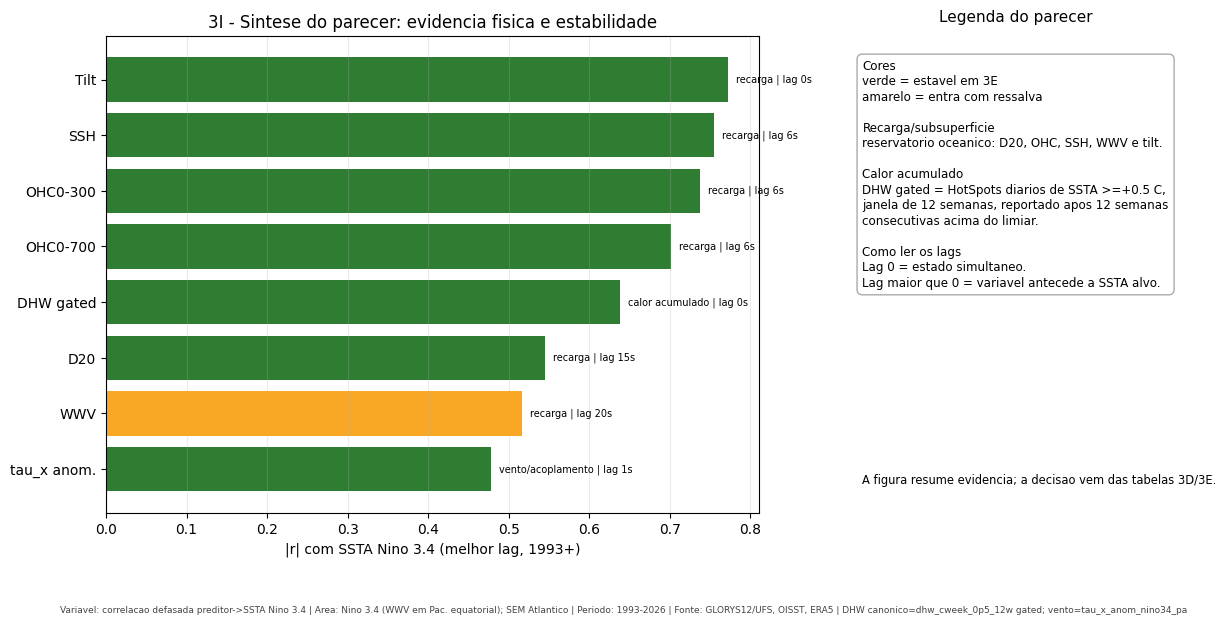

[figura] data\processed\figures\fase3\phase3I_antecipacao_pico.png


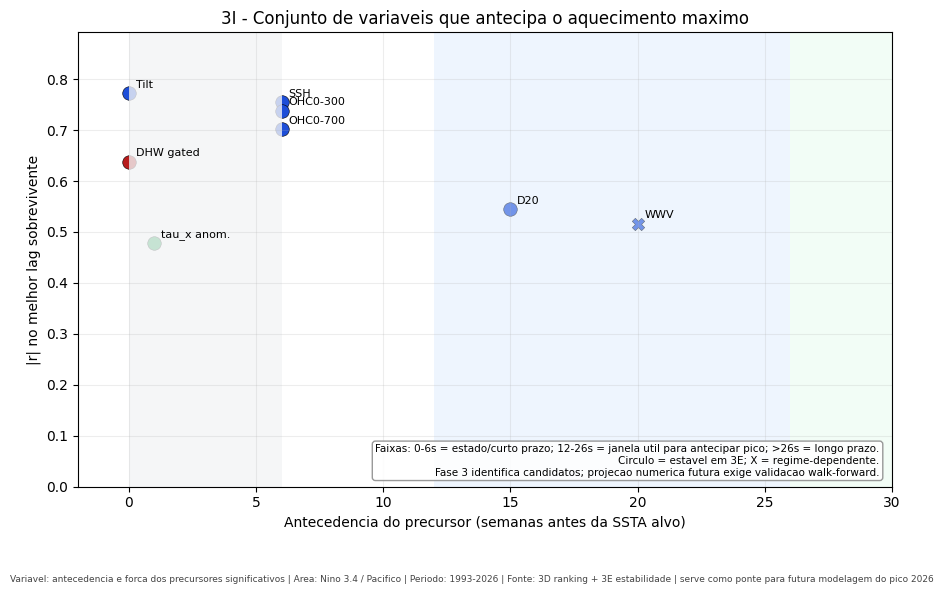

In [5]:
# Figura-sintese 1: ranking executivo e legenda de conceitos.
conc2 = conc.sort_values('abs_r', ascending=False)
fig, (ax, ax_note) = plt.subplots(1, 2, figsize=(13.8, 6.2), gridspec_kw={'width_ratios':[2.35, 1.15]})
cor = conc2['estavel_3E'].map({True:'#2e7d32', False:'#f9a825'})
y = np.arange(len(conc2))
ax.barh(y, conc2['abs_r'], color=cor)
ax.set_yticks(y)
ax.set_yticklabels(conc2['rotulo'])
for i, (_, r) in enumerate(conc2.iterrows()):
    ax.text(r['abs_r']+.01, i, f"{r['bloco'].replace('recarga/subsuperficie','recarga')} | lag {int(r['lag_semanas'])}s", va='center', fontsize=7)
ax.invert_yaxis()
ax.set_xlabel('|r| com SSTA Nino 3.4 (melhor lag, 1993+)')
ax.set_title('3I - Sintese do parecer: evidencia fisica e estabilidade')
ax.grid(axis='x', alpha=.25)
ax_note.axis('off')
ax_note.set_title('Legenda do parecer', fontsize=11, pad=10)
legend_txt = (
    'Cores\n'
    'verde = estavel em 3E\n'
    'amarelo = entra com ressalva\n\n'
    'Recarga/subsuperficie\n'
    'reservatorio oceanico: D20, OHC, SSH, WWV e tilt.\n\n'
    'Calor acumulado\n'
    'DHW gated = HotSpots diarios de SSTA >=+0.5 C,\n'
    'janela de 12 semanas, reportado apos 12 semanas\n'
    'consecutivas acima do limiar.\n\n'
    'Como ler os lags\n'
    'Lag 0 = estado simultaneo.\n'
    'Lag maior que 0 = variavel antecede a SSTA alvo.'
)
ax_note.text(0.02, 0.95, legend_txt, fontsize=8.55, va='top', ha='left', linespacing=1.25, bbox=dict(boxstyle='round,pad=.45', fc='white', ec='0.65', alpha=.95))
ax_note.text(0.02, 0.055, 'A figura resume evidencia; a decisao vem das tabelas 3D/3E.', fontsize=8.3, va='bottom', ha='left')
u.stamp_caption(fig, variavel='correlacao defasada preditor->SSTA Nino 3.4', area='Nino 3.4 (WWV em Pac. equatorial); SEM Atlantico', periodo='1993-2026', fonte='GLORYS12/UFS, OISST, ERA5', extra='DHW canonico=dhw_cweek_0p5_12w gated; vento=tau_x_anom_nino34_pa')
u.save_fig(fig, 'phase3I_sintese_parecer.png')
plt.show()

# Figura-sintese 2: quais variaveis realmente antecipam o pico.
fig, ax = plt.subplots(figsize=(10.5, 5.9))
colors = conc['bloco'].map({'recarga/subsuperficie':'#1d4ed8', 'vento/acoplamento':'#16a34a', 'calor acumulado':'#b71c1c'}).fillna('#6b7280')
markers = conc['estavel_3E'].map({True:'o', False:'X'})
for idx, r in conc.iterrows():
    ax.scatter(r['lag_semanas'], r['abs_r'], s=95 if r['estavel_3E'] else 80, color=colors.loc[idx], marker=markers.loc[idx], edgecolor='k', linewidth=.4)
    ax.annotate(r['rotulo'], (r['lag_semanas'], r['abs_r']), xytext=(5,4), textcoords='offset points', fontsize=8)
ax.axvspan(0, 6, color='#f3f4f6', alpha=.8, lw=0)
ax.axvspan(12, 26, color='#dbeafe', alpha=.45, lw=0)
ax.axvspan(26, 79, color='#dcfce7', alpha=.35, lw=0)
ax.set_xlim(-2, max(30, conc['lag_semanas'].max()+8))
ax.set_ylim(0, min(1, conc['abs_r'].max()+0.12))
ax.set_xlabel('Antecedencia do precursor (semanas antes da SSTA alvo)')
ax.set_ylabel('|r| no melhor lag sobrevivente')
ax.set_title('3I - Conjunto de variaveis que antecipa o aquecimento maximo')
ax.grid(alpha=.22)
u.add_note(ax, 'Faixas: 0-6s = estado/curto prazo; 12-26s = janela util para antecipar pico; >26s = longo prazo.\nCirculo = estavel em 3E; X = regime-dependente.\nFase 3 identifica candidatos; projecao numerica futura exige validacao walk-forward.', loc='lower right')
u.stamp_caption(fig, variavel='antecedencia e forca dos precursores significativos', area='Nino 3.4 / Pacifico', periodo='1993-2026', fonte='3D ranking + 3E estabilidade', extra='serve como ponte para futura modelagem do pico 2026')
u.save_fig(fig, 'phase3I_antecipacao_pico.png')
plt.show()


**Veredito integrado (Pacifico).** A Fase 3 identifica um conjunto fisico para antecipar o aquecimento maximo, mas ainda nao entrega uma previsao numerica do pico de 2026. O bloco de **recarga/subsuperficie** e a base: D20, SSH, OHC, WWV e tilt descrevem o reservatorio oceanico que permite a amplificacao da SSTA; `tau_x_anom` mede o acoplamento vento-superficie; `DHW` mede persistencia/severidade acumulada. Na leitura operacional: variaveis com lag positivo e estabilidade 3E sao candidatas para antecipacao; variaveis de lag 0-6 semanas sao diagnostico de estado; DHW confirma persistencia, mas nao substitui o bloco dinamico para prever pico.


In [6]:
# exporta texto integrado atualizado para o parecer
entra = ', '.join(conc[~conc['uso_parecer'].str.contains('ressalva', regex=False)]['variavel'].tolist())
ressalva = ', '.join(conc[conc['uso_parecer'].str.contains('ressalva', regex=False)]['variavel'].tolist())
prioritarios = ', '.join(antecip.query("interpreta_para_2026 == 'priorizar na futura projecao de pico'")['variavel'].tolist())
estado = est.iloc[0]
linhas = []
for _, r in media.iterrows():
    linhas.append(f"`{r['grupo']}`: n={int(r['n_eventos'])}, pico ONI medio {r['oni_pico_medio_c']} C, duracao media {r['duracao_media_estacoes_oni']} estacoes e DHW maximo medio {r['dhw_maximo_medio_c_weeks']} C-weeks.")
classes_txt = '\n\n'.join(linhas)
texto = f"""# Interpretacao integrada da Fase 3

## Veredito executivo
A Fase 3 sustenta um diagnostico fisico auditavel do Nino 3.4. O bloco de recarga/subsuperficie (D20/OHC/SSH/WWV/tilt) domina a interpretacao do aquecimento maximo; `tau_x_anom_nino34_pa` representa acoplamento vento-superficie; `dhw_cweek_0p5_12w` mede persistencia/severidade acumulada. Variaveis prioritarias para uma futura projecao do pico: {prioritarios or 'nenhuma variavel passou simultaneamente pelos criterios de antecedencia e estabilidade'}.

## Definicao NOAA/ONI local
Evento El Nino = media movel de 3 meses da SSTA Nino 3.4 >=+0.5 C por pelo menos 5 estacoes moveis sobrepostas. Intensidade = pico dessa media: fraco [0.5,1.0), moderado [1.0,1.5), forte [1.5,2.0), muito_forte >=2.0 C. O CPC/NOAA tambem exige evidencia atmosferica; aqui o acoplamento e avaliado por proxy local (`tau_x_anom_nino34_pa`), nao como declaracao oficial.

## DHW
O DHW canonico e `dhw_cweek_0p5_12w`: HotSpot diario=SSTA quando SSTA>=+0.5 C; valores abaixo do limiar viram zero; acumulo movel de 12 semanas em C-weeks; valor reportado apenas apos 12 semanas diarias consecutivas acima de +0.5 C. `oni_12w_mean_c` permanece somente como auditoria, nao como preditor publico.

## Relacoes que entram no parecer
Entram: {entra}. Entram com ressalva/regime-dependencia: {ressalva}. Relacoes instaveis nao sao descartadas automaticamente, mas nao devem ser usadas sozinhas para projetar pico.

## Classes NOAA
{classes_txt}

## Estado 2025/26
Ultimo dado diario OISST: {estado['ultimo_dia']}, SSTA diaria {estado['ssta_diaria_c']} C. Leitura: {estado['leitura']}.

## Proxima decisao
A Fase 3 prepara a Fase de previsao, mas ainda nao prova skill preditivo. O passo futuro deve testar D20/OHC/SSH/WWV/tilt/tau_x_anom/DHW contra climatologia e persistencia em validacao walk-forward para projetar o pico de 2026.
"""
out = u.STATS / 'phase3I_interpretacao_integrada.md'
out.write_text(texto, encoding='utf-8')
print(f"[texto] {out.relative_to(u.ROOT)}")


[texto] data\processed\parquet\statistics\phase3I_interpretacao_integrada.md
